In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict
import glob
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm
from nltk.stem import WordNetLemmatizer
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

# stop_words = set(stopwords.words('english'))

custom_stopwords = {
    'dont','didnt','doesnt','would','could','one','get','got',
    'really','also','even','much','many','well','make','made','still',
    'thing','things','something','anything','everything','way','lot',
    'first','second','third','time','day','week','month','year',
    'ive','im','youre','theyre','cant','wont','couldnt','wouldnt',
    'product','item','order','ordered','buy','bought', 'isnt',
    'purchase','purchased','using','use','used', 'looking','look',
    'said', 'shoe', 'box', 'came', 'work', 'put', 'door'
}

stop_words = set(stopwords.words('english')).union(custom_stopwords)


base_path = Path("/content/drive/MyDrive/Jewelry_Project/Jewelry_review_files/")
year_folders = sorted(base_path.glob("year=*"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"n't", " not", text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return tokens
def get_word_freq(token_series):
    all_words = []
    for tokens in token_series:
        all_words.extend(tokens)
    return Counter(all_words)

all_products=[]
reviews_per_brand = defaultdict(int)
for year_folder in year_folders:
    year = int(year_folder.name.split("=")[1])
    for file in year_folder.glob("*.parquet"):
        df = pd.read_parquet(file, columns=["parent_asin", "asin", "brand", "rating", 'price', "review"]) #rating here is reviewer's rating
        df = df.dropna(subset=["parent_asin", "asin", "brand", "rating", 'price',"review"])
        df["review"]=df["review"].astype(str).str.strip()
        df["brand"]=df["brand"].astype(str).str.strip()
        not_brand = {"", "unknown", "generic", "unbranded", "none", "nan", "/n"}
        df = df[~df["brand"].str.lower().isin(not_brand)]
        df["price"] = pd.to_numeric(df["price"], errors="coerce")
        df = df[df["price"] > 0]
        df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
        df = df[(df["rating"] > 0) & (df["rating"] <= 5)]
        df['year']=year
        all_products.append(df)
products=pd.concat(all_products, ignore_index=True)
products["price_segment"] = np.select([products["price"] < 100,(products["price"] >= 100) & (products["price"] <= 1000),products["price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
# products.head(10)
# print(products[products["price_segment"] == "luxury"].head(5))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [3]:
durability_words = ["break", "broken", "broke", "defect", "damaged",
                    "snap", "crack", 'snapped', 'fell apart', 'defective',
                    'faulty', 'stopped working', 'does not work', 'cheaply made',
                    'poor quality', 'flimsy', 'fragile']
# pattern = r'\b(' + '|'.join(durability_words) + r')\b'
pattern = r'\b(?:' + '|'.join(map(re.escape, durability_words)) + r')\b'

products['durability_flag'] = products['review'].str.contains(pattern, case=False, na=False)

In [4]:
product_stats = (products.groupby("parent_asin").agg(
    avg_rating=("rating", "mean"),
    total_reviews=("rating", "count"),
    durability_rate=("durability_flag", "mean"),
    price=("price", "median")).reset_index())

In [5]:
product_stats["log_price"] = np.log1p(product_stats["price"])
product_stats["price_segment"] = np.select([product_stats["price"] < 100,(product_stats["price"] >= 100) & (product_stats["price"] <= 1000),product_stats["price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
product_stats = product_stats[product_stats["total_reviews"] >= 5].copy()
product_stats.head()

,parent_asin,avg_rating,total_reviews,durability_rate,price,log_price,price_segment
2,8742240611,4.400000,15,0.133333,9.88,2.386926,cheap
5,B0000AX6DV,4.820513,39,0.076923,84.99,4.454231,cheap
6,B0000AX6DY,4.600000,5,0.000000,26.98,3.331490,cheap
8,B0000CCXWK,5.000000,10,0.000000,17.95,2.941804,cheap
10,B0000E1VVX,4.464286,28,0.035714,29.15,3.406185,cheap


In [6]:
import statsmodels.api as sm

X = product_stats[["durability_rate", "log_price", "total_reviews"]]
X = sm.add_constant(X)

y = product_stats["avg_rating"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.284
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     2848.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        06:57:22   Log-Likelihood:                -16391.
No. Observations:               21558   AIC:                         3.279e+04
Df Residuals:                   21554   BIC:                         3.282e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1942      0.014    2

<Axes: xlabel='durability_rate', ylabel='avg_rating'>

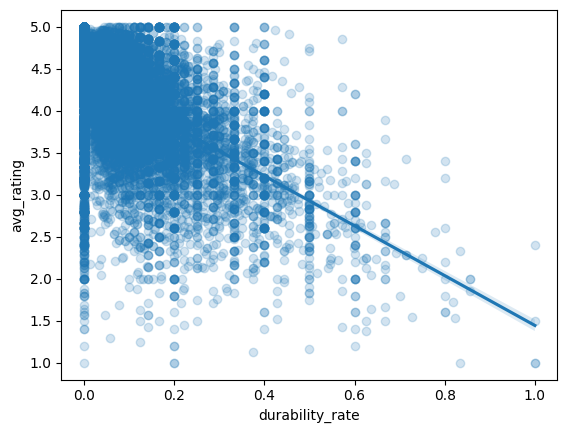

In [7]:
sns.regplot(
    data=product_stats,
    x="durability_rate",
    y="avg_rating",
    scatter_kws={"alpha": 0.2})

In [8]:
for segment in ["cheap", "mid", "luxury"]:
    subset = product_stats[product_stats["price_segment"] == segment]

    X = subset[["durability_rate", "total_reviews"]]
    X = sm.add_constant(X)

    y = subset["avg_rating"]

    model = sm.OLS(y, X).fit()

    print(f"{segment.upper()}")
    print(model.summary())

CHEAP
                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     3865.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:09:25   Log-Likelihood:                -15679.
No. Observations:               20393   AIC:                         3.136e+04
Df Residuals:                   20390   BIC:                         3.139e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.4049      0.00

In [11]:
# #compare complains types

size_words = [
    "too small", "too big", "too large", "too tight", "too loose",
    "didn't fit", "doesn't fit", "not fit", "wrong size",
    "smaller than expected", "larger than expected"
]

size_pattern = r'\b(?:' + '|'.join(map(re.escape, size_words)) + r')\b'
products["size_flag"] = products["review"].str.contains(size_pattern, case=False, na=False)



In [12]:
appearance_words = [
    "cheap looking", "looks cheap", "looked cheap",
    "ugly", "bad looking", "looks fake",
    "look fake", "fake looking", "not as pictured",
    "not like picture", "different from picture",
    "cheaply made", "looks different"
]

appearance_pattern = r'\b(?:' + '|'.join(map(re.escape, appearance_words)) + r')\b'

products["appearance_flag"] = products["review"].str.contains(appearance_pattern, case=False, na=False)

In [15]:
color_words = [
    "color faded", "faded", "color changed",
    "not same color", "different color",
    "color off", "color wrong"
]

color_pattern = r'\b(?:' + '|'.join(map(re.escape, color_words)) + r')\b'
products["color_flag"] = products["review"].str.contains(color_pattern, case=False, na=False)

In [16]:
product_stats_multi = (
    products.groupby("parent_asin")
    .agg(avg_rating=("rating", "mean"),
         total_reviews=("rating", "count"),
         durability_rate=("durability_flag", "mean"),
         size_rate=("size_flag", "mean"),
         appearance_rate=("appearance_flag", "mean"),
         color_rate=("color_flag", "mean"),
         price=("price", "median")).reset_index())

product_stats_multi["log_price"] = np.log1p(product_stats_multi["price"])
product_stats_multi["price_segment"] = np.select([product_stats_multi["price"] < 100,(product_stats_multi["price"] >= 100) & (product_stats_multi["price"] <= 1000),product_stats_multi["price"] > 1000],["cheap", "mid", "luxury"],default="unknown")
product_stats_multi = product_stats_multi[product_stats_multi["total_reviews"] >= 5]

In [17]:
X = product_stats_multi[[
    "durability_rate",
    "size_rate",
    "appearance_rate",
    "color_rate",
    "log_price",
    "total_reviews"
]]

X = sm.add_constant(X)
y = product_stats_multi["avg_rating"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     1628.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:20:28   Log-Likelihood:                -15961.
No. Observations:               21558   AIC:                         3.194e+04
Df Residuals:                   21551   BIC:                         3.199e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.2605      0.014    2

In [20]:
results = []

for segment in ["cheap", "mid", "luxury"]:
    subset = product_stats_multi[product_stats_multi["price_segment"] == segment]

    X = subset[[
        "durability_rate",
        "size_rate",
        "appearance_rate",
        "color_rate",
        "total_reviews"
    ]]
    X = sm.add_constant(X)
    y = subset["avg_rating"]

    model_seg = sm.OLS(y, X).fit()
    print(model_seg.summary())

    results.append({
        "segment": segment,
        "durability": model_seg.params["durability_rate"],
        "size": model_seg.params["size_rate"],
        "appearance": model_seg.params["appearance_rate"],
        "color": model_seg.params["color_rate"]
    })

pd.DataFrame(results)

                            OLS Regression Results                            
Dep. Variable:             avg_rating   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.304
Method:                 Least Squares   F-statistic:                     1786.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        07:42:07   Log-Likelihood:                -15252.
No. Observations:               20393   AIC:                         3.052e+04
Df Residuals:                   20387   BIC:                         3.056e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.4656      0.005    8

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sqrt(eigvals[0]/eigvals[-1])


,segment,durability,size,appearance,color
0,cheap,-2.866326,-1.696904,-1.524798,-1.575207
1,mid,-2.881448,-0.186717,-3.012381,-0.685254
2,luxury,-1.584477,0.067144,-0.468614,0.000000


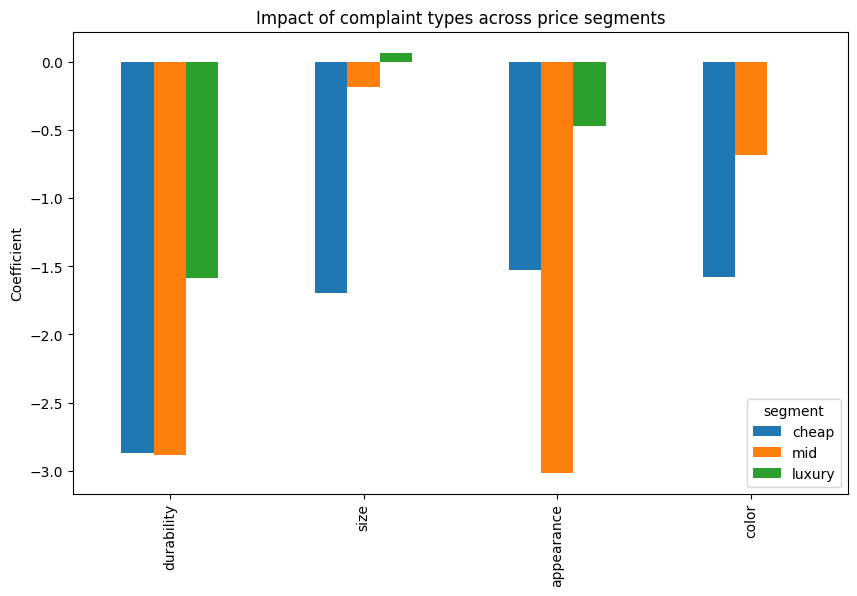

In [21]:
df_plot = pd.DataFrame(results).set_index("segment")

df_plot.T.plot(kind="bar", figsize=(10,6))
plt.title("Impact of complaint types across price segments")
plt.ylabel("Coefficient")
plt.show()